In [1]:
%pip install pandas matplotlib seaborn scikit-learn transformers ipywidgets
%pip install torch --index-url https://download.pytorch.org/whl/cu130

Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu130
Note: you may need to restart the kernel to use updated packages.


Shape: (24783, 7)


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...



Columns:
['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet']

Data types:
Unnamed: 0            int64
count                 int64
hate_speech           int64
offensive_language    int64
neither               int64
class                 int64
tweet                   str
dtype: object

Missing values:


,missing_count
Unnamed: 0,0
count,0
hate_speech,0
offensive_language,0
neither,0
class,0
tweet,0



Duplicate rows: 0

Numeric summary:


...

,count,unique,top,freq
tweet,24783,24783,!!! RT @mayasolovely: As a woman you shouldn't...,1



Created cleaned text column: tweet_clean


,tweet,tweet_clean
0,!!! RT @mayasolovely: As a woman you shouldn't...,rt as a woman you shouldn t complain about cle...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,rt boy dats cold tyga dwn bad for cuffin dat h...
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,rt dawg rt you ever fuck a bitch and she start...
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,rt she look like a tranny
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,rt the shit you hear about me might be true or...


,count,percentage
class,,
0,1430,5.77
1,19190,77.43
2,4163,16.80


C:\Users\mwper\AppData\Local\Temp\ipykernel_10560\47506999.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=target_col, order=class_counts.index, palette="viridis")


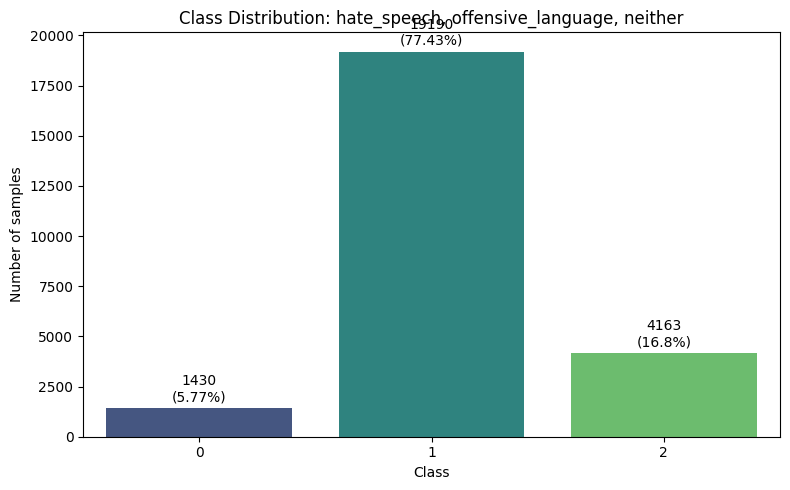


Class hate_speech - 5 examples


,class,tweet,tweet_clean
0,0,@AustinG1135 I do not like talking to you fagg...,i do not like talking to you faggot and i did ...
1,0,RT @mitchmancuso: @BrantPrintup:What straight ...,rt what straight guys take a picture of themse...
2,0,"@clinchmtn316 @sixonesixband AMERICA today, th...",america today the rule of thumb is when in dou...
3,0,"@STACCS_WNT_FOLD you tell me, coon.",you tell me coon
4,0,RT @FAAMMoverALL: This nigguh Chris Paul,rt this nigguh chris paul



Class offensive_language - 5 examples


,class,tweet,tweet_clean
0,1,Why is it everytime I go to cracker barrel the...,why is it everytime i go to cracker barrel the...
1,1,"Run that nigga, you don't want that nigga, but...",run that nigga you don t want that nigga but i...
2,1,I need a girl from Jamaica I can't fuck with t...,i need a girl from jamaica i can t fuck with t...
3,1,RT @ShadowBeatz_Inc: I know you have me blocke...,rt i know you have me blocked but next week bitch
4,1,Put ya hands up if you a Grade A bitch,put ya hands up if you a grade a bitch



Class neither - 5 examples


,class,tweet,tweet_clean
0,2,RT @chicagotribune: Chicago will not refund $7...,rt chicago will not refund million made from r...
1,2,"Sometimes, even I gotta tell these hoes to gro...",sometimes even i gotta tell these hoes to grow...
2,2,&#8216;Chillin&#8217; With My Homie Or What&#8...,chillin with my homie or what s left of him br...
3,2,.@CoryBooker is running around town delivering...,is running around town delivering food to peop...
4,2,RT @McNarstle: ...and rounding out our CNN Ebo...,rt and rounding out our cnn ebola panel tonigh...


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("../data/labeled_data.csv")

# Basic overview
print("Shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nNumeric summary:")
display(df.describe().T)

print("\nCategorical summary:")
display(df.describe(include=["object", "category"]).T if len(df.select_dtypes(include=["object", "category"]).columns) else pd.DataFrame({"info": ["No categorical columns"]}))

# Clean text column: URLs, @mentions, hashtags, special characters
text_col = "tweet" if "tweet" in df.columns else df.select_dtypes(include=["object", "category"]).columns[0]

df[f"{text_col}_clean"] = (
    df[text_col]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.replace(r"http\S+|www\.\S+", "", regex=True)   # remove URLs
    .str.replace(r"@\w+", "", regex=True)               # remove @mentions
    .str.replace(r"#(\w+)", r"\1", regex=True)          # keep hashtag word, remove #
    .str.replace(r"[^a-z\s]", " ", regex=True)          # remove special characters/numbers
    .str.replace(r"\s+", " ", regex=True)               # normalize spaces
    .str.strip()
)

print(f"\nCreated cleaned text column: {text_col}_clean")
display(df[[text_col, f"{text_col}_clean"]].head())

class_names = ["hate_speech", "offensive_language", "neither"]
target_col = "class"

# Visualize class imbalance
class_counts = df[target_col].value_counts().sort_index()
class_pct = (class_counts / len(df) * 100).round(2)

display(
    pd.DataFrame({
        "count": class_counts,
        "percentage": class_pct
    })
)

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x=target_col, order=class_counts.index, palette="viridis")

plt.title(f"Class Distribution: {', '.join(class_names)}")
plt.xlabel("Class")
plt.ylabel("Number of samples")

for i, cls in enumerate(class_counts.index):
    count = class_counts.loc[cls]
    pct = class_pct.loc[cls]
    ax.text(i, count + max(class_counts) * 0.01, f"{count}\n({pct}%)", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


sample_cols = [target_col, text_col]
clean_col = f"{text_col}_clean"
if clean_col in df.columns:
    sample_cols.append(clean_col)

for cls_value in sorted(df[target_col].dropna().unique()):
    print(f"\nClass {class_names[cls_value]} - 5 examples")
    display(
        df.loc[df[target_col] == cls_value, sample_cols]
          .sample(n=min(5, (df[target_col] == cls_value).sum()), random_state=42)
          .reset_index(drop=True)
    )